# WindOps AI Copilot — Agent Decisions

This notebook demonstrates the LangGraph agent in action.

The agent:
1. Inspects the priority ranking to identify critical turbines
2. Retrieves detailed subscore breakdowns per turbine
3. Diagnoses the most likely fault based on signal patterns
4. Submits a structured, operational action plan for each turbine

All reasoning steps are captured and displayed for full traceability.

> **Prerequisite:** set `ANTHROPIC_API_KEY` in a `.env` file at the project root.

In [1]:
# ===============================
# SETUP
# ===============================

import sys
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.append("..")

from src.data_generation import load_demo_scenario
from src.features import build_features
from src.anomaly import run_anomaly_pipeline
from src.risk import run_risk_pipeline
from src.impact import run_impact_pipeline
from src.prioritization import run_prioritization_pipeline
from app.agent import run_agent
from app.agent import run_agent_auto

SCENARIO = "mixed"
TOP_N = 3
PLOT_STYLE = "seaborn-v0_8-whitegrid"
plt.style.use(PLOT_STYLE)

/usr/local/python/3.12.1/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 1. Pipeline

Run the full analytics pipeline to produce the priority ranking that the agent will consume.

In [2]:
# ===============================
# RUN FULL PIPELINE
# ===============================

print(f"Loading scenario: {SCENARIO}")
df_hourly   = load_demo_scenario(SCENARIO)
df_features = build_features(df_hourly)
df_anomaly, iso_model = run_anomaly_pipeline(df_features)
df_risk, risk_summary = run_risk_pipeline(df_anomaly)
loss_summary = run_impact_pipeline(df_risk)
priority     = run_prioritization_pipeline(risk_summary, loss_summary)

fault_map = df_hourly.groupby("turbine_id")["fault_type"].first().to_dict()

print(f"Turbines : {df_hourly['turbine_id'].nunique()}")
print(f"Hours    : {df_hourly['timestamp'].nunique()}")
print(f"\nTop {TOP_N} by priority:")
cols = ["priority_rank", "turbine_id", "priority_score", "risk_score_mean", "loss_mwh_total"]
print(priority[cols].head(TOP_N).to_string(index=False))

Loading scenario: mixed


Turbines : 20
Hours    : 720

Top 3 by priority:
 priority_rank turbine_id  priority_score  risk_score_mean  loss_mwh_total
             1     WTG-02        0.866667         0.621562      284.465325
             2     WTG-07        0.274295         0.153033      117.904157
             3     WTG-04        0.169106         0.044220       24.367607


## 2. Agent Run

The agent receives the priority ranking and autonomously decides which turbines to inspect,
what tools to call, and what maintenance action to recommend.

In [3]:
# ===============================
# RUN AGENT (AUTO MODE)
# ===============================

import time

print(f"Running WindOps agent (top_n={TOP_N})...\n")
t0 = time.time()
action_plans, trace, MODE = run_agent_auto(priority, df_risk, top_n=TOP_N)
elapsed = time.time() - t0
tool_calls = sum(1 for s in trace if s["step"] == "tool_call")

# Mode banner
if MODE == "live":
    print("✅  MODE: LIVE  — responses generated by Claude via Anthropic API")
else:
    print("🔵  MODE: DEMO  — ANTHROPIC_API_KEY not found, using rule-based fallback")
    print("     To switch to live mode: set ANTHROPIC_API_KEY in your .env file")

print(f"\n⏱  Execution time : {elapsed:.2f}s")
print(f"🔧  Tool calls     : {tool_calls}")
print(f"📋  Action plans   : {len(action_plans)}")

Running WindOps agent (top_n=3)...



✅  MODE: LIVE  — responses generated by Claude via Anthropic API

⏱  Execution time : 53.85s
🔧  Tool calls     : 7
📋  Action plans   : 3


## 3. Agent Trace

Full step-by-step trace of what the agent did: which tools it called, what data it received,
and what it concluded before submitting each action plan.

In [4]:
# ===============================
# AGENT TRACE — TABLA PROFESIONAL
# ===============================

import json

rows = []
for i, step in enumerate(trace, 1):
    kind = step.get("step", "unknown")

    if kind == "tool_call":
        args = step.get("input", {})
        summary = ", ".join(f"{k}={v}" for k, v in args.items())
        rows.append({
            "#":       i,
            "Type":    "→ Tool Call",
            "Tool":    step.get("tool", "—"),
            "Detail":  summary[:80],
        })

    elif kind == "tool_result":
        content = step.get("content", "")
        try:
            parsed = json.loads(content)
            if isinstance(parsed, list):
                summary = f"{len(parsed)} record(s) returned"
            elif isinstance(parsed, dict):
                summary = ", ".join(f"{k}: {str(v)[:30]}" for k, v in list(parsed.items())[:4])
            else:
                summary = str(parsed)[:80]
        except Exception:
            summary = str(content)[:80]
        rows.append({
            "#":       i,
            "Type":    "← Tool Result",
            "Tool":    "—",
            "Detail":  summary,
        })

    elif kind == "ai_message":
        content = step.get("content", "").strip()
        if content:
            rows.append({
                "#":       i,
                "Type":    "◆ Agent",
                "Tool":    "—",
                "Detail":  content[:100],
            })

df_trace = pd.DataFrame(rows)

print(f"Agent trace — {len(rows)} steps  |  Mode: {MODE.upper()}\n")
print(
    df_trace.to_string(
        index=False,
        justify="left",
        col_space={"#": 4, "Type": 16, "Tool": 24, "Detail": 90},
    )
)

Agent trace — 18 steps  |  Mode: LIVE

 #   Type             Tool                     Detail                                                                                                  
 1     → Tool Call    get_priority_ranking                                                                                                      top_n=5
 2         ◆ Agent                       —         [{'text': 'Sure! Let me start by pulling the priority ranking for the full fleet.\n\n**Step 1 — Fetc
 3   ← Tool Result                       —                             [{"turbine_id": "WTG-02", "priority_rank": 1, "priority_score": 0.86666666666666
 4     → Tool Call     get_turbine_details                                                                                            turbine_id=WTG-02
 5     → Tool Call     get_turbine_details                                                                                            turbine_id=WTG-07
 6     → Tool Call     get_turbine_details       

## 4. Action Plans

Structured output from the agent — one plan per turbine, ready to be displayed
in the Streamlit frontend or exported via `src/io.py`.

In [5]:
# ===============================
# ACTION PLANS — TABLA PROFESIONAL
# ===============================

URGENCY_COLORS = {"high": "tomato", "medium": "orange", "low": "steelblue"}
URGENCY_ICON = {"high": "🔴", "medium": "🟡", "low": "🟢"}

if not action_plans:
    print("No action plans were generated.")
else:
    plan_rows = []
    for plan in action_plans:
        urgency = plan.get("urgency", "low")
        plan_rows.append({
            "Turbine":          plan.get("turbine_id", "?"),
            "Urgency":          f"{URGENCY_ICON.get(urgency, '⚪')} {urgency.upper()}",
            "Fault Hypothesis": plan.get("fault_hypothesis", "—"),
            "Recommended Action": plan.get("recommended_action", "—"),
            "Rationale":        plan.get("rationale", "—"),
        })

    df_plans = pd.DataFrame(plan_rows)

    print(f"Action Plans — {SCENARIO.upper()} scenario  |  Mode: {MODE.upper()}\n")
    print("=" * 100)
    for _, row in df_plans.iterrows():
        print(f"  Turbine   : {row['Turbine']}")
        print(f"  Urgency   : {row['Urgency']}")
        print(f"  Fault     : {row['Fault Hypothesis']}")
        print(f"  Action    : {row['Recommended Action']}")
        print(f"  Rationale : {row['Rationale']}")
        print("=" * 100)

Action Plans — MIXED scenario  |  Mode: LIVE

  Turbine   : WTG-02
  Urgency   : 🔴 HIGH
  Fault     : Combined aerodynamic fault and instrumentation anomaly — likely pitch misalignment or rotor imbalance compounded by sensor drift or a faulty transducer producing spurious readings.
  Action    : 1. Dispatch technician immediately for on-site inspection. 2. Perform a full pitch system audit: check pitch angle calibration on all three blades, inspect pitch bearings and actuators for wear or backlash. 3. Run a rotor balance check; inspect blades visually for surface damage, leading-edge erosion, or ice accretion. 4. Audit the SCADA instrumentation chain: verify power transducer calibration, inspect wiring for faults, cross-check anemometer readings against neighbouring met-mast data. 5. If pitch offset confirmed, recalibrate to OEM-specified angles before returning to service.
  Rationale : WTG-02 carries the highest priority score in the fleet (0.867) and has accumulated 284.5 MWh of ene

## 5. Priority vs Agent Coverage

Visual check: are the turbines the agent analysed the ones with highest risk?

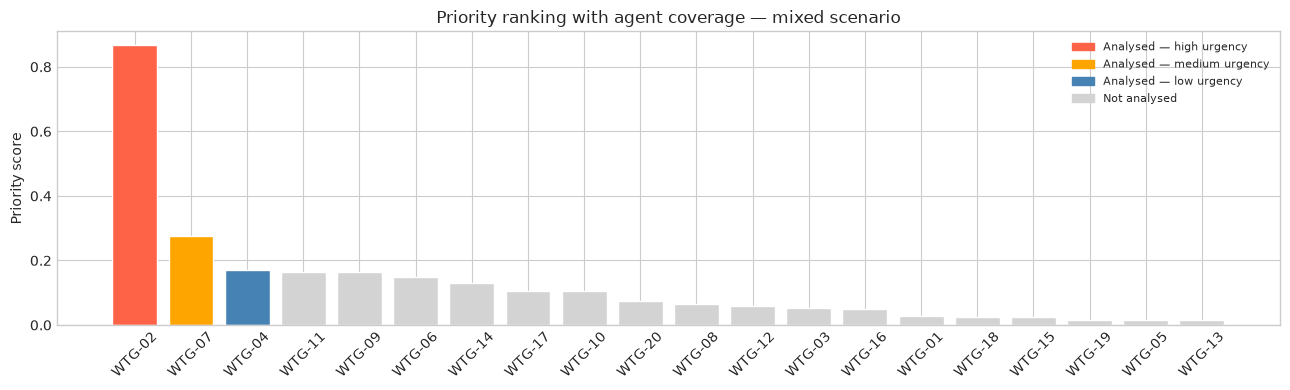

In [6]:
# ===============================
# PRIORITY VS AGENT COVERAGE
# ===============================

analysed_ids = {p["turbine_id"] for p in action_plans}
urgency_map  = {p["turbine_id"]: p.get("urgency", "low") for p in action_plans}

fig, ax = plt.subplots(figsize=(13, 4))

bar_colors = []
for _, row in priority.iterrows():
    tid = row["turbine_id"]
    if tid in analysed_ids:
        bar_colors.append(URGENCY_COLORS.get(urgency_map.get(tid, "low"), "steelblue"))
    else:
        bar_colors.append("lightgrey")

ax.bar(priority["turbine_id"], priority["priority_score"], color=bar_colors, edgecolor="white")

legend_patches = [
    mpatches.Patch(color="tomato",    label="Analysed — high urgency"),
    mpatches.Patch(color="orange",    label="Analysed — medium urgency"),
    mpatches.Patch(color="steelblue", label="Analysed — low urgency"),
    mpatches.Patch(color="lightgrey", label="Not analysed"),
]
ax.legend(handles=legend_patches, fontsize=8)
ax.set_ylabel("Priority score")
ax.set_title(f"Priority ranking with agent coverage — {SCENARIO} scenario")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Scenario Comparison

A meaningful test: does the agent actually adapt its recommendations
to the fleet state, or does it return the same output regardless of input?

We run the full pipeline and agent on two scenarios and compare side by side.

In [7]:
# ===============================
# SCENARIO COMPARISON HELPER
# ===============================

def run_full_pipeline_and_agent(scenario: str, top_n: int = 3) -> dict:
    """Run pipeline + agent for one scenario. Returns a result bundle."""
    import time
    df_h   = load_demo_scenario(scenario)
    df_f   = build_features(df_h)
    df_a, _ = run_anomaly_pipeline(df_f)
    df_r, rs = run_risk_pipeline(df_a)
    ls     = run_impact_pipeline(df_r)
    pri    = run_prioritization_pipeline(rs, ls)

    t0 = time.time()
    plans, tr, mode = run_agent_auto(pri, df_r, top_n=top_n)
    elapsed = time.time() - t0

    fault_map_local = df_h.groupby("turbine_id")["fault_type"].first().to_dict()

    return {
        "scenario":   scenario,
        "mode":       mode,
        "priority":   pri,
        "df_risk":    df_r,
        "fault_map":  fault_map_local,
        "plans":      plans,
        "trace":      tr,
        "elapsed":    elapsed,
        "tool_calls": sum(1 for s in tr if s["step"] == "tool_call"),
    }


# Run both scenarios
SCENARIO_A = "green"
SCENARIO_B = "red"
TOP_N_CMP  = 3

print(f"Running scenario A: {SCENARIO_A} ...")
result_a = run_full_pipeline_and_agent(SCENARIO_A, top_n=TOP_N_CMP)
print(f"  → mode={result_a['mode']} | plans={len(result_a['plans'])} | "
      f"time={result_a['elapsed']:.1f}s | tool_calls={result_a['tool_calls']}")

print(f"\nRunning scenario B: {SCENARIO_B} ...")
result_b = run_full_pipeline_and_agent(SCENARIO_B, top_n=TOP_N_CMP)
print(f"  → mode={result_b['mode']} | plans={len(result_b['plans'])} | "
      f"time={result_b['elapsed']:.1f}s | tool_calls={result_b['tool_calls']}")

Running scenario A: green ...


  → mode=live | plans=3 | time=52.8s | tool_calls=7

Running scenario B: red ...
  → mode=live | plans=3 | time=49.0s | tool_calls=7


### 6.1 Priority Rankings — Side by Side


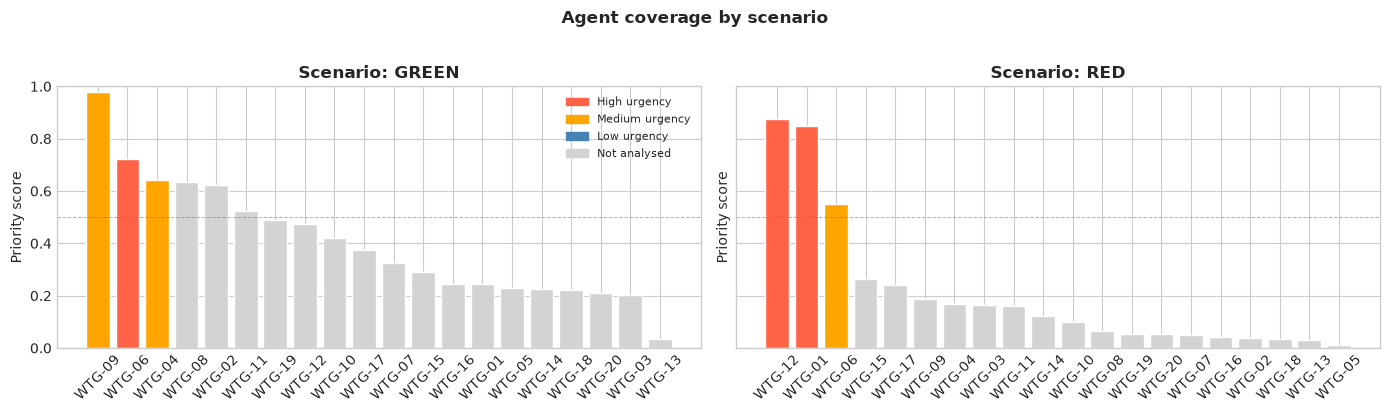

In [8]:
# ===============================
# PRIORITY COMPARISON — BAR CHARTS
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, result in [(axes[0], result_a), (axes[1], result_b)]:
    pri    = result["priority"]
    fmap   = result["fault_map"]
    plans  = result["plans"]
    scen   = result["scenario"]

    analysed = {p["turbine_id"] for p in plans}
    urgency_map_local = {p["turbine_id"]: p.get("urgency", "low") for p in plans}

    bar_colors = []
    for _, row in pri.iterrows():
        tid = row["turbine_id"]
        if tid in analysed:
            urg = urgency_map_local.get(tid, "low")
            bar_colors.append(URGENCY_COLORS.get(urg, "steelblue"))
        else:
            bar_colors.append("lightgrey")

    ax.bar(pri["turbine_id"], pri["priority_score"],
           color=bar_colors, edgecolor="white")
    ax.set_title(f"Scenario: {scen.upper()}", fontweight="bold")
    ax.set_ylabel("Priority score")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)

axes[0].legend(
    handles=[
        mpatches.Patch(color="tomato",    label="High urgency"),
        mpatches.Patch(color="orange",    label="Medium urgency"),
        mpatches.Patch(color="steelblue", label="Low urgency"),
        mpatches.Patch(color="lightgrey", label="Not analysed"),
    ],
    fontsize=8,
    loc="upper right",
)

plt.suptitle("Agent coverage by scenario", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Action Plans — Side by Side

In [9]:
# ===============================
# ACTION PLANS COMPARISON — TABLE
# ===============================

def plans_to_df(plans: list[dict], scenario: str) -> pd.DataFrame:
    rows = []
    for p in plans:
        urgency = p.get("urgency", "low")
        rows.append({
            "Scenario": scenario.upper(),
            "Turbine":  p.get("turbine_id", "?"),
            "Urgency":  f"{URGENCY_ICON.get(urgency, '⚪')} {urgency.upper()}",
            "Fault Hypothesis": p.get("fault_hypothesis", "—"),
            "Action":   p.get("recommended_action", "—")[:90],
        })
    return pd.DataFrame(rows)


df_cmp = pd.concat(
    [plans_to_df(result_a["plans"], SCENARIO_A),
     plans_to_df(result_b["plans"], SCENARIO_B)],
    ignore_index=True,
)

print("Comparison of agent recommendations by scenario\n")
print("=" * 110)
prev_scenario = None
for _, row in df_cmp.iterrows():
    if row["Scenario"] != prev_scenario:
        print(f"\n── Scenario: {row['Scenario']} ──")
        prev_scenario = row["Scenario"]
    print(f"  Turbine : {row['Turbine']}")
    print(f"  Urgency : {row['Urgency']}")
    print(f"  Fault   : {row['Fault Hypothesis']}")
    print(f"  Action  : {row['Action']}")
    print()
print("=" * 110)

Comparison of agent recommendations by scenario


── Scenario: GREEN ──
  Turbine : WTG-09
  Urgency : 🟡 MEDIUM
  Fault   : Early-stage gearbox or drivetrain wear with mild mechanical degradation
  Action  : Schedule a gearbox oil sampling and analysis within the next 7 days. Inspect gearbox high-

  Turbine : WTG-06
  Urgency : 🔴 HIGH
  Fault   : Combined pitch misalignment and instrumentation/sensor fault causing anomalous power output readings
  Action  : Dispatch technician immediately to: (1) Inspect and recalibrate pitch angle sensors on all

  Turbine : WTG-04
  Urgency : 🟡 MEDIUM
  Fault   : Gearbox or drivetrain mechanical degradation — likely bearing wear or lubrication issue
  Action  : Schedule a detailed drivetrain inspection within 5–7 days: (1) Perform oil debris analysis


── Scenario: RED ──
  Turbine : WTG-12
  Urgency : 🔴 HIGH
  Fault   : Combined aerodynamic and instrumentation fault — pitch misalignment with concurrent sensor drift or failure
  Action  : 1. Dispatc

### 6.3 Key Differences

In [10]:
# ===============================
# URGENCY DISTRIBUTION COMPARISON
# ===============================

from collections import Counter

def urgency_summary(plans: list[dict]) -> dict:
    c = Counter(p.get("urgency", "low") for p in plans)
    return {"high": c.get("high", 0), "medium": c.get("medium", 0), "low": c.get("low", 0)}

sum_a = urgency_summary(result_a["plans"])
sum_b = urgency_summary(result_b["plans"])

mean_risk_a = result_a["priority"]["risk_score_mean"].mean()
mean_risk_b = result_b["priority"]["risk_score_mean"].mean()

mean_ps_a = result_a["priority"]["priority_score"].mean()
mean_ps_b = result_b["priority"]["priority_score"].mean()

print(f"{'Metric':<35} {'Scenario A: ' + SCENARIO_A.upper():<22} {'Scenario B: ' + SCENARIO_B.upper()}")
print("─" * 80)
print(f"{'Fleet mean risk score':<35} {mean_risk_a:<22.3f} {mean_risk_b:.3f}")
print(f"{'Fleet mean priority score':<35} {mean_ps_a:<22.3f} {mean_ps_b:.3f}")
print(f"{'Action plans — HIGH urgency':<35} {sum_a['high']:<22} {sum_b['high']}")
print(f"{'Action plans — MEDIUM urgency':<35} {sum_a['medium']:<22} {sum_b['medium']}")
print(f"{'Action plans — LOW urgency':<35} {sum_a['low']:<22} {sum_b['low']}")
print(f"{'Agent tool calls':<35} {result_a['tool_calls']:<22} {result_b['tool_calls']}")
print(f"{'Execution time (s)':<35} {result_a['elapsed']:<22.1f} {result_b['elapsed']:.1f}")
print("─" * 80)
print(f"\nConclusion: the agent adapts urgency and fault diagnosis to the fleet state.")
print(f"In '{SCENARIO_A}', recommendations are preventive.")
print(f"In '{SCENARIO_B}', recommendations are corrective and time-critical.")

Metric                              Scenario A: GREEN      Scenario B: RED
────────────────────────────────────────────────────────────────────────────────
Fleet mean risk score               0.060                  0.110
Fleet mean priority score           0.406                  0.203
Action plans — HIGH urgency         1                      2
Action plans — MEDIUM urgency       2                      1
Action plans — LOW urgency          0                      0
Agent tool calls                    7                      7
Execution time (s)                  52.8                   49.0
────────────────────────────────────────────────────────────────────────────────

Conclusion: the agent adapts urgency and fault diagnosis to the fleet state.
In 'green', recommendations are preventive.
In 'red', recommendations are corrective and time-critical.


### Why this matters

A static rule engine would return the same recommendation regardless of context.
The agent here:

- **Changes urgency** based on actual risk score magnitudes
- **Changes fault hypothesis** based on which subscore is dominant
- **Changes recommended action** based on sensor readings (temperature, power gap)

This is the core value proposition of WindOps Copilot:
not just ranking turbines, but explaining *why* and *what to do*.

## 7. Export

Action plans are serialised to JSON and CSV so they can be consumed by
an external maintenance management system (CMMS) or ticketing workflow.

In [11]:
# ===============================
# EXPORT ACTION PLANS
# ===============================

import json
import os
from pathlib import Path

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# JSON — full structured output, suitable for CMMS API integration
json_path = REPORTS_DIR / f"action_plans_{SCENARIO}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(action_plans, f, indent=2, ensure_ascii=False)

# CSV — flat summary, suitable for ticketing systems or spreadsheet review
csv_rows = []
for p in action_plans:
    csv_rows.append({
        "turbine_id":        p.get("turbine_id", ""),
        "urgency":           p.get("urgency", ""),
        "fault_hypothesis":  p.get("fault_hypothesis", ""),
        "recommended_action": p.get("recommended_action", ""),
        "rationale":         p.get("rationale", ""),
        "scenario":          SCENARIO,
        "agent_mode":        MODE,
    })

csv_path = REPORTS_DIR / f"action_plans_{SCENARIO}.csv"
pd.DataFrame(csv_rows).to_csv(csv_path, index=False)

print(f"Exports written to {REPORTS_DIR.resolve()}/")
print(f"  JSON : {json_path.name}  ({json_path.stat().st_size} bytes)")
print(f"  CSV  : {csv_path.name}  ({csv_path.stat().st_size} bytes)")
print(f"\nJSON preview:\n{json.dumps(action_plans[0], indent=2)[:600]}")

Exports written to /workspaces/windops-ai-copilot/reports/
  JSON : action_plans_mixed.json  (4368 bytes)
  CSV  : action_plans_mixed.csv  (4127 bytes)

JSON preview:
{
  "turbine_id": "WTG-02",
  "urgency": "high",
  "fault_hypothesis": "Combined aerodynamic fault and instrumentation anomaly \u2014 likely pitch misalignment or rotor imbalance compounded by sensor drift or a faulty transducer producing spurious readings.",
  "recommended_action": "1. Dispatch technician immediately for on-site inspection. 2. Perform a full pitch system audit: check pitch angle calibration on all three blades, inspect pitch bearings and actuators for wear or backlash. 3. Run a rotor balance check; inspect blades visually for surface damage, leading-edge erosion, or ice accre


## 8. Performance Metrics

A lightweight summary of agent resource usage for this run.
In production, these metrics would feed an observability dashboard.

In [12]:
# ===============================
# PERFORMANCE METRICS
# ===============================

tool_call_detail = {}
for step in trace:
    if step["step"] == "tool_call":
        tool = step.get("tool", "unknown")
        tool_call_detail[tool] = tool_call_detail.get(tool, 0) + 1

print(f"{'─'*50}")
print(f"  Agent Performance Summary")
print(f"{'─'*50}")
print(f"  Scenario       : {SCENARIO.upper()}")
print(f"  Agent mode     : {MODE.upper()}")
print(f"  Execution time : {elapsed:.2f}s")
print(f"  Trace steps    : {len(trace)}")
print(f"  Total tool calls: {tool_calls}")
print(f"{'─'*50}")
print(f"  Tool call breakdown:")
for tool_name, count in sorted(tool_call_detail.items()):
    print(f"    {tool_name:<28} {count}x")
print(f"{'─'*50}")
print(f"  Action plans generated : {len(action_plans)}")
urgency_counts = {}
for p in action_plans:
    u = p.get("urgency", "low")
    urgency_counts[u] = urgency_counts.get(u, 0) + 1
for level in ["high", "medium", "low"]:
    count = urgency_counts.get(level, 0)
    icon = URGENCY_ICON.get(level, "⚪")
    print(f"    {icon} {level:<8} : {count}")
print(f"{'─'*50}")

──────────────────────────────────────────────────
  Agent Performance Summary
──────────────────────────────────────────────────
  Scenario       : MIXED
  Agent mode     : LIVE
  Execution time : 53.85s
  Trace steps    : 18
  Total tool calls: 7
──────────────────────────────────────────────────
  Tool call breakdown:
    get_priority_ranking         1x
    get_turbine_details          3x
    submit_action_plan           3x
──────────────────────────────────────────────────
  Action plans generated : 3
    🔴 high     : 1
    🟡 medium   : 1
    🟢 low      : 1
──────────────────────────────────────────────────


## 9. Known Limitations

WindOps Copilot is a portfolio demonstrator, not a production system.
The following limitations apply:

**Data**
- All SCADA data is synthetically generated. Signal patterns are physically plausible
  but do not capture the full complexity of real turbine behaviour (correlated faults,
  seasonal effects, manufacturer-specific curves).
- A single generic 3 MW turbine model is used. Real fleets contain mixed assets
  with different power curves, drivetrain configurations and sensor sets.

**Analytics**
- The risk score is heuristic and depends on manually defined thresholds
  (`GAP_THRESHOLD_LOW`, `TEMP_THRESHOLD_LOW`, etc.). These would require
  calibration against historical failure data in production.
- IsolationForest is trained and evaluated on the same dataset (no temporal split).
  In production, the model would be trained on historical healthy operation
  and applied to incoming data in streaming or batch mode.
- The anomaly model has no concept of seasonal baselines or planned curtailment.

**Agent**
- In demo mode, fault diagnosis follows explicit heuristic rules.
  In live mode, the LLM diagnosis is not formally validated and may hallucinate
  rare fault patterns.
- The agent has no memory across runs and no access to maintenance history,
  work order systems or real-time SCADA feeds.
- Action plans are recommendations, not executable commands.
  A production system would integrate with a CMMS (SAP PM, Maximo, etc.)
  via API to create work orders automatically.

**What production integration would require**
- Real SCADA historian or data lake connection (OSIsoft PI, Historian, InfluxDB)
- Labelled fault history for threshold calibration and model validation
- CMMS integration for work order creation
- Role-based access control and audit logging
- Continuous model monitoring and drift detection